In [1]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics import r2_score
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from scipy import stats

In [2]:
network_names = ["conf","school","email_eu_modified"]
# Fixed network name
fixed_network_name = network_names[0] 
network_name = network_names[0] 
# Loop through all files in the directory
directory = "../beta_regression_result_85stop_10%init_nodes-v3/unweighted/"

df_merge = pd.DataFrame()

# Loop through all files in the directory
for filename in os.listdir(directory):
    # Check if the filename matches the pattern and contains the fixed network_name
    if filename.endswith('EPH-v3.csv') and f"unweighted_simple_{fixed_network_name}_beta_" in filename:
        # Use regex to extract the beta value from the filename
        match = re.search(r"beta_([0-9.]+)_EPH-v3\.csv", filename)
        # match = re.search(r"beta_([0-9.]+)limited-node_0.1_EPH-v3\.csv", filename)
        if match:
            beta = float(match.group(1))  # Convert beta to a float
            file_path = os.path.join(directory, filename)
            df_new = pd.read_csv(file_path)
            df_new["theta"] = beta
            df_merge = pd.concat([df_merge,df_new])

In [3]:
df_merge = df_merge[~df_merge["EPH"].isna()]
# df_merge = df_merge[df_merge["theta"] > 0.021]
df_merge = df_merge.sample(frac=1,random_state=42)
X = df_merge[['EPH']]
y = df_merge['theta']

In [7]:


# Assuming X and y are already defined as Pandas DataFrames or Series
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=142, test_size=0.2)

# Polynomial Regression (Degree 2)
poly_model = make_pipeline(PolynomialFeatures(3), PolynomialFeatures(2), LinearRegression())
poly_model.fit(X_train, y_train)
y_poly_pred = poly_model.predict(X_test)

# Calculating R^2 score for polynomial regression
r2_poly = r2_score(y_test, y_poly_pred)
print(f'R² score (Polynomial, Degree 2): {r2_poly:.4f}')

# Plotting the dataset and polynomial regression line
# plt.figure(figsize=(10, 7), dpi=1200)
fig, ax = plt.subplots(figsize=(10, 7), dpi=1200)
ax.scatter(X, y,alpha=0.2, color='blue', label='Data points')
X_sorted = np.sort(X, axis=0)
ax.plot(X_sorted, poly_model.predict(X_sorted), color='green', linewidth=2, label='Polynomial Regression (Degree 2)')

ax.set_xlabel('EPH', fontsize=15)
ax.set_ylabel('q, θ=∞', fontsize=15)
# ax.set_title('Polynomial Regression Fit', fontsize=15)
# ax.legend(loc='upper left', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)

# Error analysis for inset plot
y_pred_rounded = np.round(y_poly_pred,decimals=2)
exact_match = np.sum(y_pred_rounded == y_test) / len(y_test) * 100
within_one = np.sum(np.abs(y_pred_rounded - y_test) <= 0.01) / len(y_test) * 100
greater_than_one = 100 - within_one

# Creating inset bar chart
# inset_ax = fig.add_axes([0.15, 0.15, 0.25, 0.25])  # [left, bottom, width, height]
# inset_ax = fig.add_axes([0.6, 0.45, 0.35, 0.5])  # [left, bottom, width, height]

# inset_ax.bar(['Exact Prediction', 'Error ±1', 'Error >±1'], [exact_match, within_one - exact_match, greater_than_one], color=['blue', 'orange', 'red'])
# inset_ax.set_title('Prediction Accuracy', fontsize=12)
# inset_ax.set_ylabel('Percentage', fontsize=12)
# inset_ax.tick_params(axis='both', labelsize=10)
# inset_ax.grid(False)


# Calculate residuals
residuals = y_test - y_poly_pred

# Creating inset histogram for residuals distribution
inset_ax = fig.add_axes([0.6, 0.4, 0.35, 0.5])  # [left, bottom, width, height]
inset_ax.hist(residuals, color='purple', edgecolor='black')
inset_ax.set_title('Residuals Distribution', fontsize=12)
inset_ax.set_xlabel('Residuals', fontsize=10)
inset_ax.set_ylabel('Frequency', fontsize=12)
inset_ax.tick_params(axis='both', labelsize=10)
inset_ax.grid(False)


# Save the plot as a vectorized format
# plt.savefig('polynomial_regression.svg', format='svg')
# Save as a high-resolution PDF
plt.tight_layout()
# plt.savefig(f"../plot-april-final-version/fig2-panelC_{network_name}.pdf", format="pdf", dpi=1200)
plt.show()
plt.show()

R² score (Polynomial, Degree 2): 0.9529


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_26299/804144216.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


## Merge datasets together

In [10]:
network_names = ["conf","school","email_eu_modified"]

df_all_data_sets = pd.DataFrame()

for network_name_id in network_names:
    df_merge = pd.DataFrame()
    # Fixed network name
    fixed_network_name = network_name_id 
    network_name = network_name_id
    # Loop through all files in the directory
    directory = "../beta_regression_result_85stop_10%init_nodes-v3/unweighted/"
    
    # Loop through all files in the directory
    for filename in os.listdir(directory):
        # Check if the filename matches the pattern and contains the fixed network_name
        if filename.endswith('EPH-v3.csv') and f"unweighted_simple_{fixed_network_name}_beta_" in filename:
            # Use regex to extract the beta value from the filename
            match = re.search(r"beta_([0-9.]+)_EPH-v3\.csv", filename)
            if match:
                beta = float(match.group(1))  # Convert beta to a float
                file_path = os.path.join(directory, filename)
                df_new = pd.read_csv(file_path)
                df_new["theta"] = beta
                df_merge = pd.concat([df_merge,df_new])
    df_all_data_sets
    df_all_data_sets = pd.concat([df_merge,df_all_data_sets])


In [11]:
df_merge = df_all_data_sets.copy(deep=True)
df_merge = df_merge[~df_merge["EPH"].isna()]
# df_merge = df_merge[df_merge["theta"] > 0.021]
df_merge = df_merge.sample(frac=1,random_state=42)
X = df_merge[['EPH']]
y = df_merge['theta']

R² score (Polynomial, Degree 2): 0.5327


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_26299/711126153.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


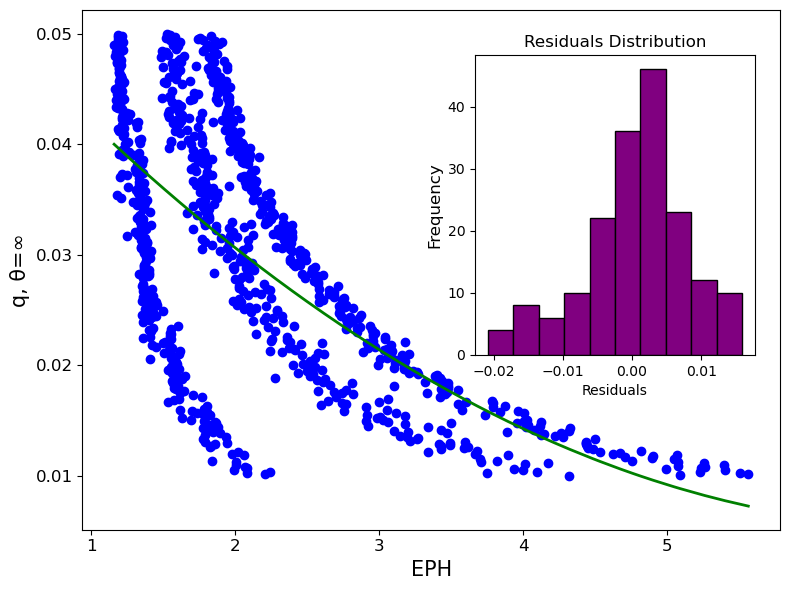

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Assuming X and y are already defined as Pandas DataFrames or Series
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=142, test_size=0.2)

# Polynomial Regression (Degree 2)
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_model.fit(X_train, y_train)
y_poly_pred = poly_model.predict(X_test)

# Calculating R^2 score for polynomial regression
r2_poly = r2_score(y_test, y_poly_pred)
print(f'R² score (Polynomial, Degree 2): {r2_poly:.4f}')

# Plotting the dataset and polynomial regression line
# plt.figure(figsize=(10, 7), dpi=1200)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X, y, color='blue', label='Data points')
X_sorted = np.sort(X, axis=0)
ax.plot(X_sorted, poly_model.predict(X_sorted), color='green', linewidth=2, label='Polynomial Regression (Degree 2)')

ax.set_xlabel('EPH', fontsize=15)
ax.set_ylabel('q, θ=∞', fontsize=15)
# ax.set_title('Polynomial Regression Fit', fontsize=15)
# ax.legend(loc='upper left', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)

# Error analysis for inset plot
y_pred_rounded = np.round(y_poly_pred,decimals=2)
exact_match = np.sum(y_pred_rounded == y_test) / len(y_test) * 100
within_one = np.sum(np.abs(y_pred_rounded - y_test) <= 0.01) / len(y_test) * 100
greater_than_one = 100 - within_one

# Creating inset bar chart
# inset_ax = fig.add_axes([0.15, 0.15, 0.25, 0.25])  # [left, bottom, width, height]
# inset_ax = fig.add_axes([0.6, 0.45, 0.35, 0.5])  # [left, bottom, width, height]

# inset_ax.bar(['Exact Prediction', 'Error ±1', 'Error >±1'], [exact_match, within_one - exact_match, greater_than_one], color=['blue', 'orange', 'red'])
# inset_ax.set_title('Prediction Accuracy', fontsize=12)
# inset_ax.set_ylabel('Percentage', fontsize=12)
# inset_ax.tick_params(axis='both', labelsize=10)
# inset_ax.grid(False)


# Calculate residuals
residuals = y_test - y_poly_pred

# Creating inset histogram for residuals distribution
inset_ax = fig.add_axes([0.6, 0.4, 0.35, 0.5])  # [left, bottom, width, height]
inset_ax.hist(residuals, color='purple', edgecolor='black')
inset_ax.set_title('Residuals Distribution', fontsize=12)
inset_ax.set_xlabel('Residuals', fontsize=10)
inset_ax.set_ylabel('Frequency', fontsize=12)
inset_ax.tick_params(axis='both', labelsize=10)
inset_ax.grid(False)


# Save the plot as a vectorized format
# plt.savefig('polynomial_regression.svg', format='svg')
# Save as a high-resolution PDF
plt.tight_layout()
plt.savefig(f"regression_simple_all_datasets_together.pdf", format="pdf", dpi=1200)
plt.show()
plt.show()

In [16]:
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.pipeline import make_pipeline
# from sklearn.metrics import r2_score
# from scipy import stats

# def bootstrap_r2_ci(X, y, model, n_bootstrap=1000, confidence=0.95, random_state=None):
#     """
#     Calculate confidence intervals for R² using bootstrap resampling.
    
#     Parameters:
#     -----------
#     X : array-like
#         Feature matrix
#     y : array-like
#         Target vector
#     model : scikit-learn model
#         Model to use for prediction
#     n_bootstrap : int, optional (default=1000)
#         Number of bootstrap samples
#     confidence : float, optional (default=0.95)
#         Confidence level for interval
#     random_state : int, optional
#         Random seed for reproducibility
    
#     Returns:
#     --------
#     r2 : float
#         Original R² score
#     ci_lower : float
#         Lower bound of confidence interval
#     ci_upper : float
#         Upper bound of confidence interval
#     """
#     rng = np.random.RandomState(random_state)
    
#     # Original R²
#     y_pred = model.predict(X)
#     r2_original = r2_score(y, y_pred)
    
#     # Bootstrap samples
#     r2_scores = []
#     n_samples = len(X)
    
#     for _ in range(n_bootstrap):
#         # Sample with replacement
#         indices = rng.randint(0, n_samples, n_samples)
#         X_boot, y_boot = X.iloc[indices], y.iloc[indices]
        
#         # Fit model and calculate R²
#         boot_model = model.fit(X_boot, y_boot)
#         y_boot_pred = boot_model.predict(X)
#         r2_boot = r2_score(y, y_boot_pred)
#         if r2_boot < 0:
#             continue
#         r2_scores.append(r2_boot)

#     for i in range(len(r2_scores)):
#         if r2_scores[i] < 0:
#             r2_scores[i] = 0
#     # print("r2_scores = ",r2_scores) 
#     # Calculate confidence intervals
#     alpha = (1 - confidence) / 2
#     ci_lower = np.percentile(r2_scores, 100 * alpha)
#     ci_upper = np.percentile(r2_scores, 100 * (1 - alpha))
    
#     return r2_original, ci_lower, ci_upper


## limited information

In [15]:
network_names = ["school","email_eu_modified","conf"]
network_names = ["school","email_eu_modified","conf"]


# Fixed network name

r2_score_family = [] 
ci_lower_family = [] 
ci_upper_family = [] 

for network_name in network_names:
    
    r2_score_list = [] 
    ci_lower_list  = [] 
    ci_upper_list  = [] 
    
    obs_ratio_list = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]
    obs_ratio_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    
    
    
    for partial_observation in tqdm(obs_ratio_list):
        fixed_network_name = network_name 
        # Loop through all files in the directory
        directory = "../beta_regression_result_85stop_10%init_nodes-v3-limited/unweighted/"
        
        df_merge = pd.DataFrame()
        
        # Loop through all files in the directory
        for filename in os.listdir(directory):
            # Check if the filename matches the pattern and contains the fixed network_name
            if filename.endswith('EPH-v3.csv') and f"unweighted_simple_{fixed_network_name}_beta_" in filename:
                # Use regex to extract the beta value from the filename
                match = re.search(r"beta_([0-9.]+)limited-node_([0-9.]+)_EPH-v3\.csv", filename)
                # match = re.search(r"beta_([0-9.]+)limited-node_0.1_EPH-v3\.csv", filename)
                # print("match1")
                if match:
                    # print("match")
                    # print(float(match.group(2)))
                    if float(match.group(2)) == partial_observation:
                        beta = float(match.group(1))  # Convert beta to a float
                        file_path = os.path.join(directory, filename)
                        df_new = pd.read_csv(file_path)
                        df_new["theta"] = beta
                        df_merge = pd.concat([df_merge,df_new])
    
                
        df_merge = df_merge[~df_merge["EPH"].isna()]
        # df_merge = df_merge[df_merge["theta"] > 0.021]
        df_merge = df_merge.sample(frac=1,random_state=42)
        X = df_merge[['EPH']]
        y = df_merge['theta']

        
    
        # Assuming X and y are already defined as Pandas DataFrames or Series
        # Splitting the dataset
        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=142, test_size=0.2)
        
        # Polynomial Regression (Degree 2)
        poly_model = make_pipeline(PolynomialFeatures(3), PolynomialFeatures(2), LinearRegression())
        poly_model.fit(X_train, y_train)
        y_poly_pred = poly_model.predict(X_test)
        
        # Calculating R^2 score for polynomial regression
        r2_poly = r2_score(y_test, y_poly_pred)
        # --- R-squared Calculation (Point Estimate) ---
        y_poly_pred_test = poly_model.predict(X_test)
        r2_poly_point_estimate = r2_score(y_test, y_poly_pred_test)

        # --- Bootstrapping for Confidence Interval ---
        n_iterations = 1000  # Number of bootstrap samples
        confidence_level = 0.95
        bootstrap_r2_scores = []
        
        # Ensure y_test is a numpy array for easier indexing if needed
        y_test_np = y_test.to_numpy() 
        # Ensure X_test is ready for prediction (it should be a DataFrame here)
        
        rng = np.random.RandomState(42) # Seed the random number generator for reproducibility
        
        for i in range(n_iterations):
            # Sample indices with replacement from the test set
            indices = rng.choice(range(len(y_test_np)), size=len(y_test_np), replace=True)
            
            # Create bootstrap samples using the sampled indices
            # Ensure X_test_bs maintains the DataFrame structure expected by the pipeline
            X_test_bs = X_test.iloc[indices] 
            y_test_bs = y_test_np[indices]
            
            # Handle cases where bootstrap sample might be trivial (e.g., all y values are the same)
            if len(np.unique(y_test_bs)) < 2:
                continue # Skip this iteration as R2 is ill-defined or 0/1
        
            # Predict using the *original* trained model
            y_pred_bs = poly_model.predict(X_test_bs)
            
            # Calculate R^2 for the bootstrap sample
            r2_bs = r2_score(y_test_bs, y_pred_bs)
            bootstrap_r2_scores.append(r2_bs)
        
        # Calculate the confidence interval using percentiles
        alpha = (1 - confidence_level) / 2.0
        lower_bound = np.percentile(bootstrap_r2_scores, alpha * 100)
        upper_bound = np.percentile(bootstrap_r2_scores, (1 - alpha) * 100)


        
        

        
        
        
        r2_score_list.append(r2_poly)
        ci_lower_list.append(lower_bound)
        ci_upper_list.append(upper_bound)

    r2_score_family.append(r2_score_list)
    ci_upper_family.append(ci_upper_list)
    ci_lower_family.append(ci_lower_list)
     

100%|█████████████████████████████████████████████| 9/9 [00:21<00:00,  2.42s/it]


In [18]:
from sklearn.metrics import mean_absolute_percentage_error

network_names = ["school","email_eu_modified","conf"]

# Fixed network name
r2_score_family = [] 
ci_lower_family = [] 
ci_upper_family = [] 

for network_name in network_names:
    
    r2_score_list = [] 
    ci_lower_list  = [] 
    ci_upper_list  = [] 
    
    obs_ratio_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    
    for partial_observation in tqdm(obs_ratio_list):
        fixed_network_name = network_name 
        # Loop through all files in the directory
        directory = "../beta_regression_result_85stop_10%init_nodes-v3-limited/unweighted/"
        
        df_merge = pd.DataFrame()
        
        # Loop through all files in the directory
        for filename in os.listdir(directory):
            if filename.endswith('EPH-v3.csv') and f"unweighted_simple_{fixed_network_name}_beta_" in filename:
                match = re.search(r"beta_([0-9.]+)limited-node_([0-9.]+)_EPH-v3\.csv", filename)
                if match:
                    if float(match.group(2)) == partial_observation:
                        beta = float(match.group(1))
                        file_path = os.path.join(directory, filename)
                        df_new = pd.read_csv(file_path)
                        df_new["theta"] = beta
                        df_merge = pd.concat([df_merge,df_new])
    
        df_merge = df_merge[~df_merge["EPH"].isna()]
        df_merge = df_merge.sample(frac=1,random_state=42)
        X = df_merge[['EPH']]
        y = df_merge['theta']

        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=142, test_size=0.2)
        
        poly_model = make_pipeline(PolynomialFeatures(3), PolynomialFeatures(2), LinearRegression())
        poly_model.fit(X_train, y_train)
        y_poly_pred = poly_model.predict(X_test)
        
        # --- MAPE Calculation (Point Estimate) ---
        mape_point_estimate = mean_absolute_percentage_error(y_test, y_poly_pred)

        # --- Bootstrapping for Confidence Interval ---
        n_iterations = 1000
        confidence_level = 0.95
        bootstrap_mape_scores = []
        
        y_test_np = y_test.to_numpy() 
        rng = np.random.RandomState(42)
        
        for i in range(n_iterations):
            indices = rng.choice(range(len(y_test_np)), size=len(y_test_np), replace=True)
            X_test_bs = X_test.iloc[indices] 
            y_test_bs = y_test_np[indices]
            
            if len(np.unique(y_test_bs)) < 2:
                continue
        
            y_pred_bs = poly_model.predict(X_test_bs)
            mape_bs = mean_absolute_percentage_error(y_test_bs, y_pred_bs)
            bootstrap_mape_scores.append(mape_bs)
        
        alpha = (1 - confidence_level) / 2.0
        lower_bound = np.percentile(bootstrap_mape_scores, alpha * 100)
        upper_bound = np.percentile(bootstrap_mape_scores, (1 - alpha) * 100)

        r2_score_list.append(mape_point_estimate)
        ci_lower_list.append(lower_bound)
        ci_upper_list.append(upper_bound)

    r2_score_family.append(r2_score_list)
    ci_upper_family.append(ci_upper_list)
    ci_lower_family.append(ci_lower_list)


100%|█████████████████████████████████████████████| 9/9 [00:23<00:00,  2.60s/it]


In [19]:
ci_upper_family

[[0.20302087670296293,
  0.1408672278514124,
  0.13807414072362745,
  0.11307611705757625,
  0.10455045778735729,
  0.08747431204644224,
  0.10788188681064936,
  0.0870890275724565,
  0.09213254479415234],
 [0.09821348255193404,
  0.07596940229354465,
  0.04516516985607037,
  0.04673982140217425,
  0.0633911354328732,
  0.03637676577082459,
  0.03753995173275656,
  0.0346472217179324,
  0.03430619510223546],
 [0.19227073555907154,
  0.12675097494617868,
  0.10473448920806565,
  0.08283808567772154,
  0.07370937275888097,
  0.08535824690373348,
  0.0894446861567202,
  0.07451911807761863,
  0.0695887123146641]]

In [20]:
ci_lower_family

[[0.1306212954983407,
  0.08663321740851745,
  0.08255015663791256,
  0.0751920347380161,
  0.062231986959717246,
  0.05972648671110052,
  0.06897588151419116,
  0.05357832083955422,
  0.05650392548918729],
 [0.06557152834228293,
  0.05113473549606266,
  0.030189492162342388,
  0.03189151897065831,
  0.03261165833572127,
  0.02381332066049503,
  0.02640139370345851,
  0.02368987605365036,
  0.023565685120276618],
 [0.11440376335296122,
  0.08796546357647846,
  0.0746176939057199,
  0.05348605509432824,
  0.055060160990271764,
  0.059290492374834136,
  0.065082081103455,
  0.051641735891359224,
  0.04749013722876277]]

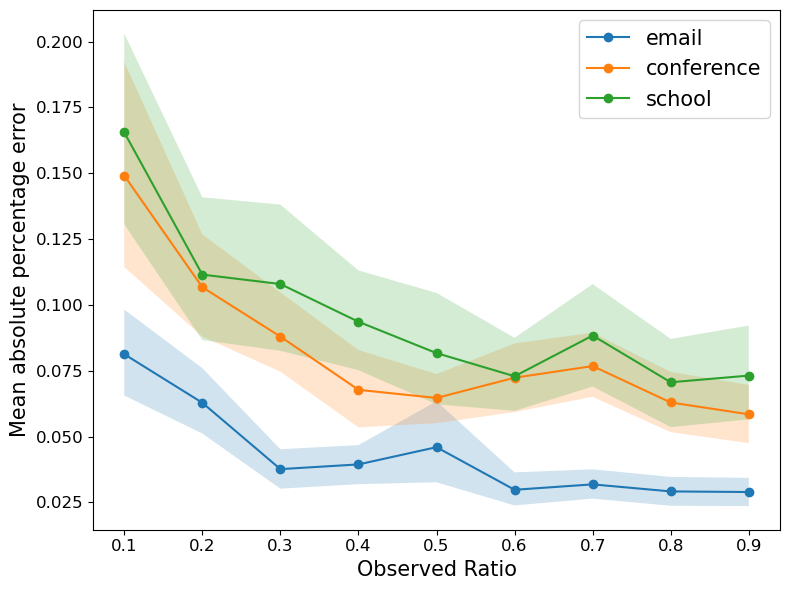

In [28]:
##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

["school","email_eu_modified","conf"]
#email
plt.plot(obs_ratio_list, r2_score_family[1], marker='o',label="email")
plt.fill_between(obs_ratio_list, ci_lower_family[1], ci_upper_family[1], alpha=0.2)

plt.plot(obs_ratio_list, r2_score_family[2], marker='o',label="conference")
plt.fill_between(obs_ratio_list, ci_lower_family[2], ci_upper_family[2], alpha=0.2)

plt.plot(obs_ratio_list, r2_score_family[0], marker='o',label="school")
plt.fill_between(obs_ratio_list, ci_lower_family[0], ci_upper_family[0], alpha=0.2)




# Set x-axis to show only integer values
plt.xticks(obs_ratio_list)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Mean absolute percentage error',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper right',fontsize=15)


# plt.grid(True) 
# plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f'../plot-april-final-version/fig4-panelC-mape.pdf', format='pdf', dpi=1200, bbox_inches='tight')
# plt.show()

In [76]:
r2_score([1,1],[1,.9])

0.0

In [ ]:

# Your existing code with confidence interval added
df_merge = df_merge[~df_merge["EPH"].isna()]
# df_merge = df_merge[df_merge["theta"] > 0.021]
df_merge = df_merge.sample(frac=1, random_state=42)
X = df_merge[['EPH']]
y = df_merge['theta']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=142, test_size=0.2)

# Polynomial Regression (Degree 2)
poly_model = make_pipeline(PolynomialFeatures(3), PolynomialFeatures(2), LinearRegression())
poly_model.fit(X_train, y_train)
y_poly_pred = poly_model.predict(X_test)

# Calculating R^2 score for polynomial regression
r2_poly = r2_score(y_test, y_poly_pred)
r2_score_list.append(r2_poly)



print(f"R² Score: {r2:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")